# 실험 2: Setting A — RetinaVLM 베이스라인 추론 + XAI 분석

**IRB 프로토콜 Setting A (Baseline):**
> 원본 OCT 이미지 + 텍스트 프롬프트 입력

RetinaVLM (ResNet50→Adapter→LLaMA3)을 사용하여 OCT 이미지에 대해
임상 보고서를 생성하고, 전체 파이프라인에 대한 XAI 분석을 수행합니다.

**입력:** 원본 OCT 이미지 + 텍스트 쿼리 (XAI 정보 없음)
**출력:** 임상 보고서 + ResNet GradCAM + LLM Attention 히트맵

**비교 대상:** 실험 3 (Setting B)의 XAI-Enhanced 결과

**파이프라인:**
```
원본 OCT → ResNet50 → Adapter → LLaMA3 → 리포트
               ↓                    ↓
          GradCAM 추출        LLM Attention 추출
               ↓                    ↓
          → 실험 3에서 Setting B와 비교
```

## 1. Imports & Hydra Config

In [38]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import torch
import json
import sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from glob import glob
from datetime import datetime
from collections import Counter
import torch.nn.functional as F
import warnings
warnings.filterwarnings("ignore")

# SpecialistVLMs 경로
SPECIALIST_DIR = os.path.abspath("../SpecialistVLMs")
if SPECIALIST_DIR not in sys.path:
    sys.path.insert(0, SPECIALIST_DIR)
os.chdir(SPECIALIST_DIR)

from huggingface_hub import hf_hub_download
from safetensors.torch import load_file as safetensors_load_file
from omegaconf import OmegaConf
from hydra import compose, initialize_config_dir
from models.retinavlm_wrapper import RetinaVLM, RetinaVLMConfig

# Hydra config
config_dir = os.path.abspath("configs")
with initialize_config_dir(version_base=None, config_dir=config_dir):
    config = compose(config_name="default")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"CUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES', 'not set')}")
print(f"Config loaded: language_model={config.model.language_model.model_id}")

Device: cuda
CUDA_VISIBLE_DEVICES: 1
Config loaded: language_model=meta-llama/Meta-Llama-3-8B-Instruct


## 2. 실험 파라미터

In [39]:
# =====================================================
#  실험 파라미터
# =====================================================

# 데이터 경로
DATA_DIR = "/home/ubuntu/bionexus/jgy/OCT_LLM_XAI/data/OCT2017/OCT2017 "
SAVE_DIR = "saved_models/RetinaVLM-Specialist-Dequantized"

# 실험 대상 클래스
CLASS_NAMES = ["NORMAL", "CNV"]

# 출력 디렉토리
EXP_DIR = "/home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments"
OUTPUT_DIR = os.path.join(EXP_DIR, "exp2_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "xai_resnet"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "xai_attention"), exist_ok=True)

# =====================================================
#  4-Task Paper-Faithful Prompts (Section 5.7)
# =====================================================

MAX_IMAGES_PER_CLASS = 25

# --- Task (a): Disease Staging — 2-step generation ---
TASK_A_QUERY = (
    "Describe the OCT image in detail and list any biomarkers or abnormalities, "
    "including the most likely AMD stage of the patient.\n"
    "Then, based on those observations, state if the patient's most advanced AMD stage is "
    "'healthy', 'early', 'intermediate', 'late dry', 'late wet (inactive)' or 'late wet (active)'?"
)
TASK_A_STEP2_PREAMBLE = "Based off the image and those findings, the patient's most advanced AMD stage is"
TASK_A_STEP1_TOKENS = 500
TASK_A_STEP2_TOKENS = 300

AMD_STAGES = [
    "late wet (active)", "late wet (inactive)", "late wet",
    "late dry", "intermediate", "early", "healthy",
]

# --- Task (b): Report — single-step generation ---
TASK_B_QUERY = (
    "Write an extensive report describing the OCT image, noting any biomarkers or "
    "abnormalities related to AMD, and their qualities. Also comment on which biomarkers are absent.\n"
    "Finally, based on the image and these findings, your report should estimate the AMD disease "
    "stage of the patient.\n"
    "You should not include any patient referral recommendations in your report, but you can "
    "comment if they need treatment with anti-vegf."
)
TASK_B_TOKENS = 500

# --- Task (c): Patient Referral — 2-step generation ---
TASK_C_QUERY = (
    "Write an extensive report describing the OCT image and listing any present biomarkers "
    "or other observations. Do not provide a disease stage, or referral recommendation yet.\n\n"
    "Being seen by a specialist at the Southampton clinic:\n"
    "A. The Southampton clinic requires that patients with any sign of intraretinal fluid, any sign "
    "of subretinal fluid, or any sign of cyst(s), MUST be seen by a specialist at the Southampton "
    "clinic within the next two weeks.\n"
    "B. The Southampton clinic requires that patients who do not have any sign of intraretinal fluid, "
    "any sign of subretinal fluid, or any sign of cyst(s), but do have some biomarkers of early or "
    "intermediate AMD, should be seen by a specialist at the Southampton clinic for routine referral.\n"
    "C. The Southampton clinic requires that patients who do not have any sign of intraretinal fluid, "
    "any sign of subretinal fluid, or any sign of cyst(s), but do have medium to large drusen, "
    "drusenoid PED, hypertransmission or atrophy, should be seen by a specialist at the Southampton "
    "clinic for routine referral.\n"
    "D. The Southampton clinic does not need to see patients who have no biomarkers and healthy "
    "retinas at all.\n\n"
    "Southampton specialist visit: Next, tell me if your initial report of the OCT image indicates "
    "that the patient should be seen by a specialist at the Southampton clinic \"within the next two "
    "weeks\", to be seen \"within 18 weeks (routine referral)\", or \"not be seen\" at all?"
)
TASK_C_STEP2_PREAMBLE = "My report indicates that the patient"
TASK_C_STEP1_TOKENS = 500
TASK_C_STEP2_TOKENS = 300

REFERRAL_CATEGORIES = {
    "within the next two weeks": "CNV",
    "two weeks": "CNV",
    "within 18 weeks": "CNV",
    "routine referral": "CNV",
    "not be seen": "NORMAL",
}

# --- Task (d): Biomarker Analysis — 2-step x 10 biomarkers ---
BIOMARKER_SPECS = [
    ("subretinal fluid", "is"),
    ("intraretinal fluid", "is"),
    ("pigment epithelial detachment", "is"),
    ("drusen", "are"),
    ("retinal pigment epithelium atrophy", "is"),
    ("geographic atrophy", "is"),
    ("subretinal hyperreflective material", "is"),
    ("hyperreflective foci", "are"),
    ("choroidal neovascularization", "is"),
    ("epiretinal membrane", "is"),
]

TASK_D_QUERY_TEMPLATE = (
    "Describe the OCT image in detail and list all biomarkers or abnormalities. "
    "Detail if there are any signs indicating that {biomarker} might be present, even if there is "
    "only a small amount.\n"
    "Finally, conclude your findings by telling me if {biomarker} {article} \"not present\", or if "
    "potentially any amount of {biomarker} {article} \"present\" in the OCT image."
)
TASK_D_STEP2_TEMPLATE = "To conclude these findings, in the OCT image {biomarker} {article}"
TASK_D_STEP1_TOKENS = 500
TASK_D_STEP2_TOKENS = 300

RUN_TASK_D = False

In [ ]:
# =====================================================
#  Helper Functions: 2-step / single-step query + extractors
# =====================================================
import re

def two_step_query(model, image_np, query, step2_preamble, step1_tokens=500, step2_tokens=300):
    """Run a 2-step generation: Step 1 generates a report, Step 2 completes with a preamble.
    Returns: (step1_text, step2_text, full_text, step1_output_tokens)
      - step1_output_tokens: Step 1 생성의 output token IDs (VL-Saliency 재사용용)
    """
    img_tensor = model.convert_any_image_to_normalized_tensor(image_np)
    param = next(model.model.parameters())
    images = torch.stack([img_tensor]).to(device=param.device, dtype=param.dtype)

    # Step 1: generate report (return_samples=True로 output_tokens 확보)
    step1_out, step1_samples = model.model.query(
        images, [query], answer_preamble=[''],
        max_new_tokens=step1_tokens, output_only=True,
        return_samples=True
    )
    step1_text = step1_out[0]
    step1_output_tokens = step1_samples['Output tokens'][0].cpu()

    # Step 2: completion with preamble
    preamble = step1_text.strip() + "\n" + step2_preamble
    step2_out = model.model.query(
        images, [query], answer_preamble=[preamble],
        max_new_tokens=step2_tokens, output_only=True
    )
    step2_text = step2_out[0]

    return step1_text, step2_text, preamble + step2_text, step1_output_tokens


def single_step_query(model, image_np, query, max_tokens=500):
    """Run a single-step generation."""
    img_tensor = model.convert_any_image_to_normalized_tensor(image_np)
    param = next(model.model.parameters())
    images = torch.stack([img_tensor]).to(device=param.device, dtype=param.dtype)

    out = model.model.query(
        images, [query], answer_preamble=[''],
        max_new_tokens=max_tokens, output_only=True
    )
    return out[0]


def extract_amd_stage(text):
    """Extract AMD stage from text, checking most specific stages first."""
    text_lower = text.lower()
    for stage in AMD_STAGES:
        if stage in text_lower:
            return stage
    return "unknown"


def extract_referral(text):
    """Extract referral level from text."""
    text_lower = text.lower()
    # Check most specific first
    if "within the next two weeks" in text_lower or "two weeks" in text_lower:
        return "within the next two weeks"
    if "within 18 weeks" in text_lower or "routine referral" in text_lower:
        return "within 18 weeks (routine referral)"
    if "not be seen" in text_lower or "does not need" in text_lower:
        return "not be seen"
    return "unknown"


def extract_biomarker_presence(text):
    """Extract present/not present from biomarker analysis text."""
    text_lower = text.lower()
    # Check 'not present' first (more specific)
    if "not present" in text_lower:
        return "not present"
    if "present" in text_lower:
        return "present"
    return "unknown"


print("Helper functions defined: two_step_query (with output_tokens), single_step_query, extract_amd_stage, extract_referral, extract_biomarker_presence")

## 3. RetinaVLM 모델 로드 (Method 1: Dequantized)

In [41]:
# Config 로드
rvlm_config = RetinaVLMConfig.from_pretrained(
    "RobbieHolland/RetinaVLM", subfolder="RetinaVLM-Specialist"
)
rvlm_config.update(config)
rvlm_config.model.checkpoint_path = None

# 모델 생성
print("Creating RetinaVLM model...")
model = RetinaVLM(rvlm_config)

# Dequantized state_dict 로드
print("Loading dequantized checkpoint...")
state_dict = torch.load(os.path.join(SAVE_DIR, "model.pt"), map_location="cpu")
missing, unexpected = model.load_state_dict(state_dict, strict=False)
print(f"  Loaded: {len(state_dict) - len(unexpected)} keys | "
      f"Missing: {len(missing)} | Unexpected: {len(unexpected)}")
del state_dict

model.to(DEVICE)
model.eval()
print(f"\nRetinaVLM ready on {DEVICE} (Method 1: Dequantized, 0 missing keys)")

Creating RetinaVLM model...
Creating new MiniGPT4 model
Loading image encoder
Creating blank encoder for later weight loading.
Loading image encoder Done
Loading language model


Loading weights: 100%|██████████| 291/291 [00:04<00:00, 65.26it/s] 


Loading language model Done
Linear projection Linear(in_features=2048, out_features=4096, bias=True)
MiniGPT-4 has 8392704 trainable parameters
Creating an entirely new MiniGPT4 adapter (this will be overwritten by pretrained model if loaded from API)
Loading dequantized checkpoint...
  Loaded: 1220 keys | Missing: 0 | Unexpected: 0

RetinaVLM ready on cuda (Method 1: Dequantized, 0 missing keys)


In [ ]:
# =====================================================
#  4-Task Inference Loop (Paper-Faithful Prompts)
# =====================================================

# Collect test images
test_images = []
for cls_name in CLASS_NAMES:
    cls_dir = os.path.join(DATA_DIR, "test", cls_name)
    files = sorted(glob(os.path.join(cls_dir, "*.jpeg")) +
                   glob(os.path.join(cls_dir, "*.png")))
    if MAX_IMAGES_PER_CLASS:
        files = files[:MAX_IMAGES_PER_CLASS]
    for f in files:
        test_images.append({"path": f, "class": cls_name})

print(f"Total test images: {len(test_images)}")
for cls in CLASS_NAMES:
    n = sum(1 for t in test_images if t["class"] == cls)
    print(f"  {cls}: {n}")

# Run 4-task inference
all_results = []

# ★ Task A의 output_tokens를 저장할 dict (VL-Saliency / Per-Token Attention 재사용)
task_a_tokens_cache = {}
TOKENS_CACHE_DIR = os.path.join(OUTPUT_DIR, "task_a_tokens")
os.makedirs(TOKENS_CACHE_DIR, exist_ok=True)

print(f"\nRunning 4-task inference (a=staging, b=report, c=referral" +
      (", d=biomarkers)" if RUN_TASK_D else ")"))
print("=" * 70)

for i, item in enumerate(test_images):
    image_np = np.array(Image.open(item["path"]).convert("L"))
    fname = os.path.basename(item["path"])
    fname_base = os.path.splitext(fname)[0]
    result = {
        "image": fname,
        "class": item["class"],
        "path": item["path"],
    }

    # --- Task (a): Disease Staging (2-step) ---
    t0 = time.time()
    with torch.no_grad():
        a_report, a_completion, a_full, a_output_tokens = two_step_query(
            model, image_np, TASK_A_QUERY, TASK_A_STEP2_PREAMBLE,
            TASK_A_STEP1_TOKENS, TASK_A_STEP2_TOKENS
        )
    a_time = time.time() - t0
    a_stage = extract_amd_stage(a_completion)

    # ★ output_tokens 캐시 (메모리 + 디스크)
    task_a_tokens_cache[fname_base] = {
        "output_tokens": a_output_tokens,
        "generated_text": a_report,
    }
    torch.save(a_output_tokens, os.path.join(TOKENS_CACHE_DIR, f"{fname_base}_tokens.pt"))

    result.update({
        "task_a_report": a_report,
        "task_a_completion": a_completion,
        "task_a_stage": a_stage,
        "task_a_time": round(a_time, 2),
    })

    # --- Task (b): Report (single-step) ---
    t0 = time.time()
    with torch.no_grad():
        b_report = single_step_query(model, image_np, TASK_B_QUERY, TASK_B_TOKENS)
    b_time = time.time() - t0

    result.update({
        "task_b_report": b_report,
        "task_b_time": round(b_time, 2),
    })

    # --- Task (c): Patient Referral (2-step) ---
    t0 = time.time()
    with torch.no_grad():
        c_report, c_completion, c_full, _ = two_step_query(
            model, image_np, TASK_C_QUERY, TASK_C_STEP2_PREAMBLE,
            TASK_C_STEP1_TOKENS, TASK_C_STEP2_TOKENS
        )
    c_time = time.time() - t0
    c_referral = extract_referral(c_completion)
    c_binary = REFERRAL_CATEGORIES.get(c_referral, "NORMAL")

    result.update({
        "task_c_report": c_report,
        "task_c_completion": c_completion,
        "task_c_referral": c_referral,
        "task_c_binary": c_binary,
        "task_c_time": round(c_time, 2),
    })

    # --- Task (d): Biomarker Analysis (optional, 2-step x 10) ---
    if RUN_TASK_D:
        t0 = time.time()
        biomarker_results = {}
        for biomarker, article in BIOMARKER_SPECS:
            query_d = TASK_D_QUERY_TEMPLATE.format(biomarker=biomarker, article=article)
            preamble_d = TASK_D_STEP2_TEMPLATE.format(biomarker=biomarker, article=article)
            with torch.no_grad():
                d_report, d_completion, d_full, _ = two_step_query(
                    model, image_np, query_d, preamble_d,
                    TASK_D_STEP1_TOKENS, TASK_D_STEP2_TOKENS
                )
            presence = extract_biomarker_presence(d_completion)
            biomarker_results[biomarker] = {
                "presence": presence,
                "completion": d_completion,
            }
        d_time = time.time() - t0
        result.update({
            "task_d_biomarkers": biomarker_results,
            "task_d_time": round(d_time, 2),
        })

    all_results.append(result)

    # Progress report every 5 images
    if (i + 1) % 5 == 0 or i == 0:
        total_time = result["task_a_time"] + result["task_b_time"] + result["task_c_time"]
        if RUN_TASK_D:
            total_time += result.get("task_d_time", 0)
        print(f"  [{i+1}/{len(test_images)}] {fname[:35]}... | {item['class']} | "
              f"stage={a_stage} | referral={c_referral[:20]} | {total_time:.1f}s")

print("=" * 70)
avg_time = np.mean([r["task_a_time"] + r["task_b_time"] + r["task_c_time"] for r in all_results])
print(f"Total: {len(all_results)} images | avg {avg_time:.1f}s/image (tasks a+b+c)")
print(f"Task A output tokens cached: {len(task_a_tokens_cache)} images → {TOKENS_CACHE_DIR}/")

# Save results
results = all_results  # alias for backward compatibility with downstream cells

df_results = pd.DataFrame([{k: v for k, v in r.items() if k != "task_d_biomarkers"} for r in all_results])
df_results.to_csv(os.path.join(OUTPUT_DIR, "inference_results.csv"), index=False)
with open(os.path.join(OUTPUT_DIR, "inference_results.json"), "w") as f:
    json.dump(all_results, f, indent=2, ensure_ascii=False)
print(f"Results saved to {OUTPUT_DIR}/")

In [43]:
# =====================================================
#  Per-Task Classification Accuracy (NORMAL vs CNV)
# =====================================================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_true = [r["class"] for r in all_results]

# --- Task (a): Disease Staging Distribution ---
print("=" * 60)
print(" Task (a) Disease Staging -- Stage Distribution")
print("=" * 60)
stage_dist = Counter(r["task_a_stage"] for r in all_results)
print(f"Stage distribution: {dict(stage_dist)}")
for cls in CLASS_NAMES:
    cls_stages = Counter(r["task_a_stage"] for r in all_results if r["class"] == cls)
    print(f"  {cls}: {dict(cls_stages)}")

# --- Task (c): Patient Referral -> Binary ---
y_pred_c = [r["task_c_binary"] for r in all_results]
print("\n" + "=" * 60)
print(" Task (c) Patient Referral -- Binary Classification")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_true, y_pred_c):.3f}")
print(classification_report(y_true, y_pred_c, target_names=CLASS_NAMES, zero_division=0))
print("Confusion Matrix:")
cm_c = confusion_matrix(y_true, y_pred_c, labels=CLASS_NAMES)
print(pd.DataFrame(cm_c, index=[f"True {c}" for c in CLASS_NAMES],
                   columns=[f"Pred {c}" for c in CLASS_NAMES]))

# Referral distribution
ref_dist = Counter(r["task_c_referral"] for r in all_results)
print(f"\nReferral distribution: {dict(ref_dist)}")

# --- Sample responses ---
print("\n" + "=" * 60)
print(" Sample Responses")
print("=" * 60)

# Task (a) samples
for cls in CLASS_NAMES:
    sample = next(r for r in all_results if r["class"] == cls)
    print(f"\n--- Task (a) | {cls} | stage={sample['task_a_stage']} ---")
    print(f"Report: {sample['task_a_report'][:200]}...")
    print(f"Completion: {sample['task_a_completion'][:150]}...")

# Task (b) samples
for cls in CLASS_NAMES:
    sample = next(r for r in all_results if r["class"] == cls)
    print(f"\n--- Task (b) | {cls} ---")
    print(f"Report: {sample['task_b_report'][:250]}...")

 Task (a) Disease Staging -- Stage Distribution
Stage distribution: {'healthy': 35, 'early': 5, 'late wet (inactive)': 1, 'late wet (active)': 6, 'late dry': 3}
  NORMAL: {'healthy': 24, 'early': 1}
  CNV: {'late wet (inactive)': 1, 'early': 4, 'late wet (active)': 6, 'healthy': 11, 'late dry': 3}

 Task (c) Patient Referral -- Binary Classification
Accuracy: 0.540
              precision    recall  f1-score   support

      NORMAL       1.00      0.08      0.15        25
         CNV       0.52      1.00      0.68        25

    accuracy                           0.54        50
   macro avg       0.76      0.54      0.42        50
weighted avg       0.76      0.54      0.42        50

Confusion Matrix:
             Pred NORMAL  Pred CNV
True NORMAL           25         0
True CNV              23         2

Referral distribution: {'not be seen': 27, 'unknown': 12, 'within 18 weeks (routine referral)': 9, 'within the next two weeks': 2}

 Sample Responses

--- Task (a) | NORMAL | stage=

In [44]:
# =====================================================
#  Hallucination Detection (Based on Task (a) Stage Predictions)
# =====================================================
# For NORMAL images: if task_a_stage is any "late wet" variant → hallucination (false positive)
# For CNV images: if task_a_stage is healthy/early/intermediate/late dry → missed detection (false negative)

LATE_WET_STAGES = {"late wet (active)", "late wet (inactive)", "late wet"}
NON_WET_STAGES = {"healthy", "early", "intermediate", "late dry"}

hall_results = []
for r in all_results:
    entry = {
        "image": r["image"],
        "class": r["class"],
        "task_a_stage": r["task_a_stage"],
        "n_hallucinations": 0,
        "details": [],
    }

    if r["class"] == "NORMAL":
        # False positive: normal image predicted as having late wet AMD
        if r["task_a_stage"] in LATE_WET_STAGES:
            entry["n_hallucinations"] = 1
            entry["details"].append({
                "type": "false_positive",
                "keyword": f"stage={r['task_a_stage']} on NORMAL image",
            })
    elif r["class"] == "CNV":
        # False negative: CNV image predicted as non-wet stage
        if r["task_a_stage"] in NON_WET_STAGES or r["task_a_stage"] == "unknown":
            entry["n_hallucinations"] = 1
            entry["details"].append({
                "type": "false_negative",
                "keyword": f"stage={r['task_a_stage']} on CNV image (missed detection)",
            })

    hall_results.append(entry)

# Summary
print("=" * 60)
print(" Setting A Hallucination / Misclassification Analysis")
print("=" * 60)

total = len(hall_results)
with_hall = sum(1 for h in hall_results if h["n_hallucinations"] > 0)
print(f"  Total: {with_hall}/{total} ({with_hall/total*100:.1f}%) misclassified")

for cls in CLASS_NAMES:
    cls_hall = [h for h in hall_results if h["class"] == cls]
    cls_with = sum(1 for h in cls_hall if h["n_hallucinations"] > 0)
    hall_type = "false positives" if cls == "NORMAL" else "false negatives (missed)"
    print(f"  {cls}: {cls_with}/{len(cls_hall)} ({cls_with/len(cls_hall)*100:.1f}%) — {hall_type}")

    # Stage breakdown for misclassified
    if cls_with > 0:
        stages = Counter(h["task_a_stage"] for h in cls_hall if h["n_hallucinations"] > 0)
        print(f"    Stages: {dict(stages)}")

# Save (same filename for backward compatibility)
with open(os.path.join(OUTPUT_DIR, "hallucination_baseline.json"), "w") as f:
    json.dump(hall_results, f, indent=2, ensure_ascii=False)
print(f"\n  Saved to {OUTPUT_DIR}/hallucination_baseline.json")

 Setting A Hallucination / Misclassification Analysis
  Total: 18/50 (36.0%) misclassified
  NORMAL: 0/25 (0.0%) — false positives
  CNV: 18/25 (72.0%) — false negatives (missed)
    Stages: {'early': 4, 'healthy': 11, 'late dry': 3}

  Saved to /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp2_outputs/hallucination_baseline.json


## 6. ResNet Visual Encoder XAI (GradCAM)

In [45]:
# ResNet visual encoder에 GradCAM 적용
inner = model.model  # MiniGPT4 instance

# GradCAM을 위한 hook 설정
gradcam_data = {"activations": None, "gradients": None}

def save_act(m, i, o):
    gradcam_data["activations"] = o.detach()

def save_grad(m, gi, go):
    gradcam_data["gradients"] = go[0].detach()

# ResNet의 layer4에 hook 등록
target_layer = inner.visual_encoder.model.layer4
hook_fwd = target_layer.register_forward_hook(save_act)
hook_bwd = target_layer.register_full_backward_hook(save_grad)

print("Generating ResNet GradCAM heatmaps...")

import scipy.ndimage

model_param = next(inner.parameters())
model_dtype = model_param.dtype
model_device = model_param.device

n_xai = len(test_images)  # 전체 테스트 이미지
xai_resnet_results = []

for idx in range(n_xai):
    item = test_images[idx]
    img_np = np.array(Image.open(item["path"]).convert("L"))
    fname_base = os.path.splitext(os.path.basename(item["path"]))[0]

    # 이미지 전처리 (RetinaVLM wrapper와 동일)
    img_arr = img_np[np.newaxis, :, :].copy()  # [1,H,W]
    if img_arr.shape[1] != 192 or img_arr.shape[2] != 192:
        zoom_factors = [1, 192 / img_arr.shape[1], 192 / img_arr.shape[2]]
        img_arr = scipy.ndimage.zoom(img_arr, zoom_factors, order=1)
    img_arr = img_arr.astype(np.float32) / 255.0
    img_tensor = torch.from_numpy(img_arr).unsqueeze(0).to(device=model_device, dtype=model_dtype)
    img_tensor.requires_grad_(True)

    # ResNet backbone 수동 forward
    backbone = inner.visual_encoder.model
    x = backbone.conv1(img_tensor)
    x = backbone.bn1(x)
    x = backbone.relu(x)
    x = backbone.maxpool(x)
    x = backbone.layer1(x)
    x = backbone.layer2(x)
    x = backbone.layer3(x)
    x = backbone.layer4(x)

    target = x.mean()
    target.backward()

    if gradcam_data["gradients"] is not None and gradcam_data["activations"] is not None:
        grads = gradcam_data["gradients"]
        acts = gradcam_data["activations"]
        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * acts).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=(224, 224), mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().detach().numpy()
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        # 저장
        save_path = os.path.join(OUTPUT_DIR, "xai_resnet", f"{fname_base}_resnet_gradcam.png")
        npy_path = os.path.join(OUTPUT_DIR, "xai_resnet", f"{fname_base}_resnet_gradcam.npy")
        display_img = np.array(Image.open(item["path"]).convert("L").resize((224, 224)))

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(display_img, cmap="gray")
        axes[0].set_title(f"{item['class']}", fontsize=10); axes[0].axis("off")
        axes[1].imshow(display_img, cmap="gray")
        axes[1].imshow(cam, cmap="jet", alpha=0.5)
        axes[1].set_title("ResNet GradCAM", fontsize=10); axes[1].axis("off")
        plt.tight_layout()
        plt.savefig(save_path, dpi=100, bbox_inches="tight")
        plt.close()

        np.save(npy_path, cam)
        xai_resnet_results.append({"image": fname_base, "class": item["class"],
                                   "file_png": save_path, "file_npy": npy_path})

    if (idx + 1) % 10 == 0 or idx == 0:
        print(f"  [{idx+1}/{n_xai}] {fname_base} ({item['class']})")

    inner.zero_grad()

hook_fwd.remove()
hook_bwd.remove()

# 결과 저장
with open(os.path.join(OUTPUT_DIR, "xai_resnet", "resnet_gradcam_results.json"), "w") as f:
    json.dump(xai_resnet_results, f, indent=2, ensure_ascii=False)
print(f"\nResNet GradCAM: {len(xai_resnet_results)}/{n_xai} saved to {OUTPUT_DIR}/xai_resnet/")

Generating ResNet GradCAM heatmaps...
  [1/50] NORMAL-1017237-1 (NORMAL)
  [10/50] NORMAL-112928-1 (NORMAL)
  [20/50] NORMAL-15307-1 (NORMAL)
  [30/50] CNV-103044-1 (CNV)
  [40/50] CNV-103044-8 (CNV)
  [50/50] CNV-1188386-2 (CNV)

ResNet GradCAM: 50/50 saved to /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp2_outputs/xai_resnet/


## 7. LLM Attention 시각화

In [46]:
# =====================================================
# LLM Attention 히트맵 추출 및 시각화
# =====================================================

inner = model.model  # MiniGPT4 instance
llm_hf = inner.llama_model  # HuggingFace LlamaForCausalLM

# 1) sdpa → eager 전환 (output_attentions 지원을 위해)
llm_hf.config._attn_implementation = "eager"
for layer in llm_hf.model.layers:
    layer.self_attn._attn_implementation = "eager"
print("Switched LLM attention to 'eager' mode")

# 2) 이미지 전처리 함수 (RetinaVLM wrapper와 동일)
def prepare_image_tensor(img_np, device, dtype):
    """numpy grayscale → [1,1,192,192] normalized tensor"""
    if img_np.ndim == 2:
        img_np = img_np[np.newaxis, :, :]  # [1,H,W]
    import scipy.ndimage
    if img_np.shape[1] != 192 or img_np.shape[2] != 192:
        zoom_factors = [1, 192 / img_np.shape[1], 192 / img_np.shape[2]]
        img_np = scipy.ndimage.zoom(img_np, zoom_factors, order=1)
    if not np.issubdtype(img_np.dtype, np.floating):
        img_np = img_np.astype(np.float32) / 255.0
    return torch.from_numpy(img_np).unsqueeze(0).to(device=device, dtype=dtype)

# 3) Attention 추출 & 시각화
n_attn = len(test_images)  # 전체 테스트 이미지
attn_results = []
query_text_attn = TASK_A_QUERY  # Task (a) 쿼리 사용

print(f"\nExtracting LLM attention for {n_attn} images...")
print("-" * 60)

model_param = next(inner.parameters())
model_dtype = model_param.dtype
model_device = model_param.device

for idx in range(n_attn):
    item = test_images[idx]
    img_np = np.array(Image.open(item["path"]).convert("L"))
    fname_base = os.path.splitext(os.path.basename(item["path"]))[0]

    # 이미지 텐서 준비
    img_tensor = prepare_image_tensor(img_np, model_device, model_dtype)

    try:
        with torch.no_grad():
            samples, tokens, subseq_indices, seq_attentions, _ = inner.attention(
                img_tensor, [query_text_attn]
            )

        pre_len, img_len, post_len = subseq_indices[0]

        # 텍스트 토큰 → 이미지 토큰 attention
        text_to_img_attn = seq_attentions[:, 0, :, pre_len + img_len:, pre_len:pre_len + img_len]
        avg_attn = text_to_img_attn.mean(dim=(0, 1, 2)).numpy()

        # 6x6 공간 그리드로 복원
        spatial_size = int(np.sqrt(img_len))
        if spatial_size * spatial_size == img_len:
            attn_map = avg_attn.reshape(spatial_size, spatial_size)
        else:
            attn_map = avg_attn[:spatial_size * spatial_size].reshape(spatial_size, spatial_size)

        # 정규화
        if attn_map.max() > attn_map.min():
            attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())

        # 원본 해상도로 업스케일
        from PIL import Image as PILImage
        attn_upscaled = np.array(PILImage.fromarray(attn_map.astype(np.float32)).resize(
            (224, 224), PILImage.BILINEAR))

        # 시각화 & 저장
        display_img = np.array(Image.open(item["path"]).convert("L").resize((224, 224)))
        save_path = os.path.join(OUTPUT_DIR, "xai_attention", f"{fname_base}_llm_attention.png")
        npy_path = os.path.join(OUTPUT_DIR, "xai_attention", f"{fname_base}_llm_attention.npy")

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(display_img, cmap="gray")
        axes[0].set_title(f"{item['class']}", fontsize=10); axes[0].axis("off")
        axes[1].imshow(attn_map, cmap="hot", interpolation="nearest")
        axes[1].set_title(f"LLM Attention ({spatial_size}x{spatial_size})", fontsize=10); axes[1].axis("off")
        axes[2].imshow(display_img, cmap="gray")
        axes[2].imshow(attn_upscaled, cmap="hot", alpha=0.5)
        axes[2].set_title("LLM Attention Overlay", fontsize=10); axes[2].axis("off")
        plt.suptitle(f"{fname_base} | img_tokens={img_len} | layers={seq_attentions.shape[0]}", fontsize=9)
        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close()

        np.save(npy_path, attn_map)

        attn_results.append({
            "image": fname_base,
            "class": item["class"],
            "img_tokens": int(img_len),
            "spatial_size": spatial_size,
            "attn_mean": float(avg_attn.mean()),
            "attn_max": float(avg_attn.max()),
            "file_png": save_path,
            "file_npy": npy_path,
        })

    except Exception as e:
        print(f"  [{idx+1}/{n_attn}] {fname_base} - ERROR: {e}")
        import traceback; traceback.print_exc()

    if (idx + 1) % 10 == 0 or idx == 0:
        print(f"  [{idx+1}/{n_attn}] {fname_base} ({item['class']})")

    torch.cuda.empty_cache()

# 결과 저장
with open(os.path.join(OUTPUT_DIR, "xai_attention", "llm_attention_results.json"), "w") as f:
    json.dump(attn_results, f, indent=2, ensure_ascii=False)

print(f"\n{'='*60}")
print(f"LLM Attention heatmaps: {len(attn_results)}/{n_attn} saved")
print(f"Output: {OUTPUT_DIR}/xai_attention/")
print(f"{'='*60}")

Switched LLM attention to 'eager' mode

Extracting LLM attention for 50 images...
------------------------------------------------------------
  [1/50] NORMAL-1017237-1 (NORMAL)
  [10/50] NORMAL-112928-1 (NORMAL)
  [20/50] NORMAL-15307-1 (NORMAL)
  [30/50] CNV-103044-1 (CNV)
  [40/50] CNV-103044-8 (CNV)
  [50/50] CNV-1188386-2 (CNV)

LLM Attention heatmaps: 50/50 saved
Output: /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp2_outputs/xai_attention/


## 7.5 Per-Token LLM Attention (키워드별 히트맵)

기존 Section 7에서는 모든 생성 토큰의 attention을 평균하여 하나의 히트맵만 생성했습니다.
여기서는 **특정 키워드 토큰이 생성될 때 이미지의 어떤 영역을 참조하는지** 개별 히트맵을 생성합니다.

핵심 로직:
1. `query()`로 텍스트 생성
2. 생성된 텍스트를 `answer_preamble`로 넣어 `attention()` 재호출
3. 생성 토큰 중 키워드 위치의 attention만 선별하여 히트맵 생성

In [ ]:
# =====================================================
# Per-Token LLM Attention: 키워드별 히트맵 (Setting A)
# =====================================================
# ★ 수정: inference에서 저장한 task_a_tokens_cache를 재사용하여
#    동일한 생성 텍스트로 attention 분석 (재생성으로 인한 불일치 방지)

import scipy.ndimage

inner = model.model  # MiniGPT4 instance
llm_hf = inner.llama_model

# sdpa -> eager
llm_hf.config._attn_implementation = "eager"
for layer in llm_hf.model.layers:
    layer.self_attn._attn_implementation = "eager"

KEYWORDS = [
    "fluid", "drusen", "atrophy", "neovascularization",
    "healthy", "early", "intermediate", "late",
    "present", "absent", "normal", "abnormal",
]

os.makedirs(os.path.join(OUTPUT_DIR, "xai_pertoken_attention"), exist_ok=True)

model_param = next(inner.parameters())
model_dtype, model_device = model_param.dtype, model_param.device

tokenizer = inner.llama_tokenizer if hasattr(inner, 'llama_tokenizer') else inner.get_tokenizer()

n_imgs = len(test_images)
pertoken_results = []

# ★ 캐시가 메모리에 없으면 디스크에서 로드
if not task_a_tokens_cache:
    print("Loading task_a_tokens_cache from disk...")
    for r in all_results:
        fb = os.path.splitext(r["image"])[0]
        pt_path = os.path.join(TOKENS_CACHE_DIR, f"{fb}_tokens.pt")
        if os.path.exists(pt_path):
            task_a_tokens_cache[fb] = {
                "output_tokens": torch.load(pt_path, weights_only=True),
                "generated_text": r["task_a_report"],
            }

print(f"\nPer-Token LLM Attention (Setting A) for {n_imgs} images")
print(f"  Keywords: {KEYWORDS}")
print(f"  ★ Using cached tokens from inference ({len(task_a_tokens_cache)} images)")
print("-" * 60)

for idx in range(n_imgs):
    item = test_images[idx]
    img_np = np.array(Image.open(item["path"]).convert("L"))
    fname_base = os.path.splitext(os.path.basename(item["path"]))[0]
    cls_label = item["class"]

    # ★ 캐시에서 생성 텍스트 로드 (재생성 없음)
    if fname_base not in task_a_tokens_cache:
        print(f"  [{idx+1}] {fname_base}: SKIP (no cached tokens)")
        continue
    cached = task_a_tokens_cache[fname_base]
    generated_text = cached["generated_text"]

    img_arr = img_np[np.newaxis, :, :].copy()
    if img_arr.shape[1] != 192 or img_arr.shape[2] != 192:
        zoom_factors = [1, 192 / img_arr.shape[1], 192 / img_arr.shape[2]]
        img_arr = scipy.ndimage.zoom(img_arr, zoom_factors, order=1)
    if not np.issubdtype(img_arr.dtype, np.floating):
        img_arr = img_arr.astype(np.float32) / 255.0
    img_tensor = torch.from_numpy(img_arr).unsqueeze(0).to(device=model_device, dtype=model_dtype)

    keyword_maps = {}
    try:
        print(f"  [{idx+1}] Using cached text: {generated_text[:80]}...")

        # ★ 캐시된 텍스트를 answer_preamble로 넣어서 attention 추출
        with torch.no_grad():
            samples, tokens, subseq_indices, seq_attentions, _ = inner.attention(
                img_tensor, [TASK_A_QUERY], answer_preamble=[generated_text]
            )

        pre_len, img_len, post_len = subseq_indices[0]
        spatial_size = int(np.sqrt(img_len))

        # post 영역 = query + 생성 텍스트 토큰
        post_tokens = tokens[0, pre_len + img_len:].cpu()
        post_text = tokenizer.decode(post_tokens, skip_special_tokens=True)

        # text -> image attention: [layers, batch, heads, post_len, img_len]
        text_to_img = seq_attentions[:, 0, :, pre_len + img_len:, pre_len:pre_len + img_len]
        # 레이어 & 헤드 평균 -> [post_len, img_len]
        text_to_img_avg = text_to_img.mean(dim=(0, 1)).numpy()

        # 각 키워드별 히트맵 추출
        for kw in KEYWORDS:
            positions = []
            for kw_variant in [kw, " " + kw, kw.capitalize(), " " + kw.capitalize()]:
                kw_token_ids = tokenizer.encode(kw_variant, add_special_tokens=False)
                out_list = post_tokens.tolist()
                for start in range(len(out_list) - len(kw_token_ids) + 1):
                    if out_list[start:start + len(kw_token_ids)] == kw_token_ids:
                        positions.extend(range(start, start + len(kw_token_ids)))

            if not positions:
                continue

            positions = sorted(set(positions))
            kw_attn = text_to_img_avg[positions, :].mean(axis=0)

            if spatial_size * spatial_size == img_len:
                attn_map = kw_attn.reshape(spatial_size, spatial_size)
            else:
                attn_map = kw_attn[:spatial_size * spatial_size].reshape(spatial_size, spatial_size)

            if attn_map.max() > attn_map.min():
                attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())

            keyword_maps[kw] = attn_map

        if keyword_maps:
            display_img = np.array(Image.open(item["path"]).convert("L").resize((224, 224)))
            n_kw = len(keyword_maps)
            fig, axes = plt.subplots(1, n_kw + 1, figsize=(3.5 * (n_kw + 1), 3.5))
            if n_kw + 1 == 1:
                axes = [axes]

            axes[0].imshow(display_img, cmap="gray")
            axes[0].set_title(f"{cls_label}\n(original)", fontsize=8)
            axes[0].axis("off")

            for ki, (kw, amap) in enumerate(keyword_maps.items()):
                attn_up = np.array(Image.fromarray(amap.astype(np.float32)).resize(
                    (224, 224), Image.BILINEAR))
                axes[ki + 1].imshow(display_img, cmap="gray")
                axes[ki + 1].imshow(attn_up, cmap="hot", alpha=0.5)
                axes[ki + 1].set_title('"' + kw + '"', fontsize=8)
                axes[ki + 1].axis("off")

            plt.suptitle(f"{fname_base} | Per-Token LLM Attention (Setting A)", fontsize=9)
            plt.tight_layout()
            save_path = os.path.join(OUTPUT_DIR, "xai_pertoken_attention",
                                     f"{fname_base}_pertoken_attn.png")
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
            plt.close()

            for kw, amap in keyword_maps.items():
                np.save(os.path.join(OUTPUT_DIR, "xai_pertoken_attention",
                                     f"{fname_base}_{kw}_attn.npy"), amap)

            pertoken_results.append({
                "image": fname_base, "class": cls_label,
                "keywords_found": list(keyword_maps.keys()),
                "generated_text": generated_text[:200],
            })
            print(f"    -> keywords found: {list(keyword_maps.keys())}")
        else:
            print(f"    -> no keywords matched in cached text")

    except Exception as e:
        print(f"  [{idx+1}] Per-Token Attention error: {e}")
        import traceback; traceback.print_exc()

    torch.cuda.empty_cache()

with open(os.path.join(OUTPUT_DIR, "xai_pertoken_attention", "pertoken_results.json"), "w") as f:
    json.dump(pertoken_results, f, indent=2, ensure_ascii=False)

print(f"\nPer-Token Attention (Setting A): {len(pertoken_results)}/{n_imgs} saved")
print(f"Output: {OUTPUT_DIR}/xai_pertoken_attention/")

## 7.6 Visual-Language Saliency Map (키워드별 GradCAM)

RetinaVLM 논문의 핵심 XAI 기법: 특정 키워드의 LLM logit에 대해 visual encoder를 역전파하여,
**해당 단어가 생성될 때 이미지의 어떤 영역이 기여했는지** gradient 기반 saliency map을 생성합니다.

- Per-Token Attention: LLM 내부 attention weight 직접 추출 (forward pass only)
- VL-Saliency: gradient를 visual encoder까지 **역전파** (backward pass)

In [ ]:
# =====================================================
# Visual-Language Saliency Map: 키워드별 GradCAM (Setting A)
# =====================================================
# ★ 수정: inference에서 저장한 task_a_tokens_cache를 재사용하여
#    동일한 생성 텍스트/토큰으로 GradCAM 수행 (재생성으로 인한 불일치 방지)

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import scipy.ndimage

inner = model.model

for name, param in inner.visual_encoder.named_parameters():
    param.requires_grad = True

# ★ visual encoder를 float32로 변환 (GradCAM eigen_smooth SVD가 float16 미지원)
inner.visual_encoder.float()

# ★ autocast를 비활성화 (encode_img 내부의 maybe_autocast가 float16으로 되돌리는 것 방지)
import contextlib
_original_autocast = inner.maybe_autocast
inner.maybe_autocast = lambda dtype=None: contextlib.nullcontext()

target_layers = [inner.visual_encoder.model.layer4[-1]]

VL_KEYWORDS = [
    "fluid", "drusen", "atrophy", "neovascularization",
    "healthy", "early", "intermediate", "late",
    "present", "absent",
]

os.makedirs(os.path.join(OUTPUT_DIR, "xai_vl_saliency"), exist_ok=True)

model_param = next(inner.parameters())
model_dtype, model_device = model_param.dtype, model_param.device
tokenizer = inner.llama_tokenizer if hasattr(inner, 'llama_tokenizer') else inner.get_tokenizer()

def find_subsequences_multi(kw, tokenizer, output_tokens):
    """키워드의 여러 토크나이즈 변형을 시도하여 위치를 찾습니다."""
    t_list = output_tokens.tolist() if hasattr(output_tokens, 'tolist') else list(output_tokens)
    all_positions = []
    best_variant = None

    for kw_variant in [kw, " " + kw, kw.capitalize(), " " + kw.capitalize()]:
        kw_ids = tokenizer.encode(kw_variant, add_special_tokens=False)
        for start in range(len(t_list) - len(kw_ids) + 1):
            if t_list[start:start + len(kw_ids)] == kw_ids:
                if best_variant is None:
                    best_variant = (kw_ids, start)
                all_positions.append(start)

    return best_variant, all_positions

# ★ 캐시가 메모리에 없으면 디스크에서 로드
if not task_a_tokens_cache:
    print("Loading task_a_tokens_cache from disk...")
    for r in all_results:
        fb = os.path.splitext(r["image"])[0]
        pt_path = os.path.join(TOKENS_CACHE_DIR, f"{fb}_tokens.pt")
        if os.path.exists(pt_path):
            task_a_tokens_cache[fb] = {
                "output_tokens": torch.load(pt_path, weights_only=True),
                "generated_text": r["task_a_report"],
            }

n_imgs = len(test_images)
vl_saliency_results = []
original_forward = inner.forward

print(f"\nVisual-Language Saliency Map (Setting A) for {n_imgs} images")
print(f"  Keywords: {VL_KEYWORDS}")
print(f"  ★ Using cached tokens from inference ({len(task_a_tokens_cache)} images)")
print("-" * 60)

for idx in range(n_imgs):
    item = test_images[idx]
    img_np = np.array(Image.open(item["path"]).convert("L"))
    fname_base = os.path.splitext(os.path.basename(item["path"]))[0]
    cls_label = item["class"]

    # ★ 캐시에서 생성 텍스트 & output_tokens 로드 (재생성 없음)
    if fname_base not in task_a_tokens_cache:
        print(f"  [{idx+1}] {fname_base}: SKIP (no cached tokens)")
        continue
    cached = task_a_tokens_cache[fname_base]
    generated = cached["generated_text"]
    output_tokens = cached["output_tokens"]

    img_arr = img_np[np.newaxis, :, :].copy()
    if img_arr.shape[1] != 192 or img_arr.shape[2] != 192:
        zoom_factors = [1, 192 / img_arr.shape[1], 192 / img_arr.shape[2]]
        img_arr = scipy.ndimage.zoom(img_arr, zoom_factors, order=1)
    if not np.issubdtype(img_arr.dtype, np.floating):
        img_arr = img_arr.astype(np.float32) / 255.0
    # ★ float32로 입력 (visual encoder가 float32이므로)
    img_tensor = torch.from_numpy(img_arr).unsqueeze(0).to(device=model_device, dtype=torch.float32)

    keyword_cams = {}
    try:
        questions = [TASK_A_QUERY]
        outputs_text = [generated]
        print(f"  [{idx+1}] Using cached ({len(output_tokens)} tokens): {generated[:80]}...")

        # ★ inner.query() 호출 제거 — 캐시된 토큰 사용

        # 2) 각 키워드별 GradCAM
        for kw in VL_KEYWORDS:
            best, positions = find_subsequences_multi(kw, tokenizer, output_tokens)

            if best is None:
                continue

            kw_ids, first_pos = best

            # output_position: generate()의 output에서의 상대 위치 (음수 인덱스)
            output_position = first_pos - len(output_tokens)
            class_tokens_positions = np.arange(
                output_position, output_position + len(kw_ids)
            )

            # forward를 softmax_logits로 오버라이드 (closure 변수 캡처)
            _q = list(questions)
            _o = list(outputs_text)
            _ctp = class_tokens_positions.copy()
            _ct = list(kw_ids)
            inner.forward = lambda x, _q=_q, _o=_o, _ctp=_ctp, _ct=_ct: \
                inner.softmax_logits(
                    x, texts=_q, answer_preambles=_o,
                    class_tokens_positions=_ctp, class_tokens=_ct
                )

            try:
                cam = GradCAM(model=inner, target_layers=target_layers)
                targets = [ClassifierOutputTarget(0)]
                grayscale_cam = cam(
                    input_tensor=img_tensor, targets=targets,
                    eigen_smooth=True, aug_smooth=False
                )
                cam_map = grayscale_cam.squeeze()
                keyword_cams[kw] = cam_map
            except Exception as e:
                print(f"    GradCAM for '{kw}' failed: {e}")
            finally:
                inner.forward = original_forward
                inner.zero_grad()

        # 3) 시각화
        if keyword_cams:
            display_img = np.array(Image.open(item["path"]).convert("L").resize((224, 224)))
            n_kw = len(keyword_cams)
            fig, axes = plt.subplots(1, n_kw + 1, figsize=(3.5 * (n_kw + 1), 3.5))
            if n_kw + 1 == 1:
                axes = [axes]

            axes[0].imshow(display_img, cmap="gray")
            axes[0].set_title(f"{cls_label}\n(original)", fontsize=8)
            axes[0].axis("off")

            for ki, (kw, cam_map) in enumerate(keyword_cams.items()):
                if cam_map.shape != (224, 224):
                    cam_up = np.array(Image.fromarray(cam_map.astype(np.float32)).resize(
                        (224, 224), Image.BILINEAR))
                else:
                    cam_up = cam_map

                axes[ki + 1].imshow(display_img, cmap="gray")
                axes[ki + 1].imshow(cam_up, cmap="jet", alpha=0.5)
                axes[ki + 1].set_title('"' + kw + '"\n(VL-Saliency)', fontsize=8)
                axes[ki + 1].axis("off")

                np.save(os.path.join(OUTPUT_DIR, "xai_vl_saliency",
                                     f"{fname_base}_{kw}_saliency.npy"), cam_map)

            plt.suptitle(f"{fname_base} | VL-Saliency Map (Setting A)", fontsize=9)
            plt.tight_layout()
            save_path = os.path.join(OUTPUT_DIR, "xai_vl_saliency",
                                     f"{fname_base}_vl_saliency.png")
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
            plt.close()

            vl_saliency_results.append({
                "image": fname_base, "class": cls_label,
                "keywords_found": list(keyword_cams.keys()),
                "generated_text": generated[:200],
            })
            print(f"    -> saliency keywords: {list(keyword_cams.keys())}")
        else:
            print(f"    -> no keywords matched in cached tokens")

    except Exception as e:
        print(f"  [{idx+1}] VL-Saliency error: {e}")
        import traceback; traceback.print_exc()

    torch.cuda.empty_cache()

for name, param in inner.visual_encoder.named_parameters():
    param.requires_grad = False
inner.visual_encoder.half()  # ★ float16으로 복원
inner.maybe_autocast = _original_autocast  # ★ autocast 복원
inner.forward = original_forward

with open(os.path.join(OUTPUT_DIR, "xai_vl_saliency", "vl_saliency_results.json"), "w") as f:
    json.dump(vl_saliency_results, f, indent=2, ensure_ascii=False)

print(f"\nVL-Saliency Map (Setting A): {len(vl_saliency_results)}/{n_imgs} saved")
print(f"Output: {OUTPUT_DIR}/xai_vl_saliency/")

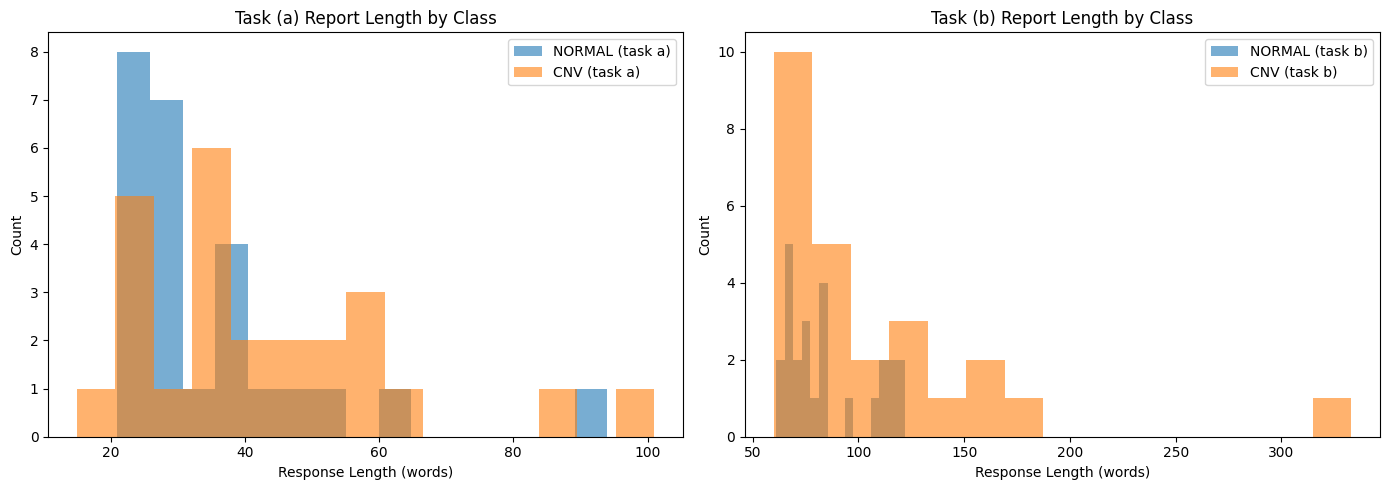


 Experiment 2 Complete (4-Task Paper-Faithful Prompts)
 Task (a) Stage Distribution: {'healthy': 35, 'early': 5, 'late wet (inactive)': 1, 'late wet (active)': 6, 'late dry': 3}
 Task (c) Referral Accuracy: 54.0%
 Hallucination Rate:         36.0%
 Inference Results: /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp2_outputs/inference_results.csv
 ResNet XAI:        /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp2_outputs/xai_resnet/
 LLM Attention:     /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/experiments/exp2_outputs/xai_attention/


In [49]:
# =====================================================
#  Results Summary & Experiment Log
# =====================================================

# Per-task accuracy metrics
y_true = [r["class"] for r in all_results]
task_c_acc = accuracy_score(y_true, [r["task_c_binary"] for r in all_results])

# Response length stats
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, cls in enumerate(CLASS_NAMES):
    cls_data = [r for r in all_results if r["class"] == cls]
    a_words = [len(r["task_a_report"].split()) for r in cls_data]
    b_words = [len(r["task_b_report"].split()) for r in cls_data]
    axes[0].hist(a_words, bins=15, alpha=0.6, label=f"{cls} (task a)")
    axes[1].hist(b_words, bins=15, alpha=0.6, label=f"{cls} (task b)")

axes[0].set_xlabel("Response Length (words)"); axes[0].set_ylabel("Count")
axes[0].set_title("Task (a) Report Length by Class"); axes[0].legend()
axes[1].set_xlabel("Response Length (words)"); axes[1].set_ylabel("Count")
axes[1].set_title("Task (b) Report Length by Class"); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "response_stats.png"), dpi=150, bbox_inches="tight")
plt.show()

# Experiment log with per-task metrics
log = {
    "experiment": "exp2_retinavlm_baseline_4task",
    "method": "method1_dequantized",
    "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S"),
    "device": str(DEVICE),
    "tasks": ["a_staging", "b_report", "c_referral"] + (["d_biomarkers"] if RUN_TASK_D else []),
    "total_images": len(all_results),
    "per_class": {cls: sum(1 for r in all_results if r["class"] == cls) for cls in CLASS_NAMES},
    "task_a_stage_distribution": dict(Counter(r["task_a_stage"] for r in all_results)),
    "task_c_accuracy": round(task_c_acc, 4),
    "task_c_referral_distribution": dict(Counter(r["task_c_referral"] for r in all_results)),
    "avg_time_per_image_sec": round(np.mean([
        r["task_a_time"] + r["task_b_time"] + r["task_c_time"] for r in all_results
    ]), 2),
    "hallucination_rate": round(sum(1 for h in hall_results if h["n_hallucinations"] > 0) / len(hall_results), 4),
}
with open(os.path.join(OUTPUT_DIR, "experiment_log.json"), "w") as f:
    json.dump(log, f, indent=2, ensure_ascii=False)

print(f"\n{'='*60}")
print(f" Experiment 2 Complete (4-Task Paper-Faithful Prompts)")
print(f"{'='*60}")
print(f" Task (a) Stage Distribution: {dict(Counter(r['task_a_stage'] for r in all_results))}")
print(f" Task (c) Referral Accuracy: {task_c_acc:.1%}")
print(f" Hallucination Rate:         {log['hallucination_rate']:.1%}")
print(f" Inference Results: {OUTPUT_DIR}/inference_results.csv")
print(f" ResNet XAI:        {OUTPUT_DIR}/xai_resnet/")
print(f" LLM Attention:     {OUTPUT_DIR}/xai_attention/")
print(f"{'='*60}")